## A. CSV Data Source - California Housing

The California Housing dataset is obtained using Scikit-learn.
The dataset contains information about housing districts in California
and will be saved as a CSV file in the data/raw folder.

In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from pathlib import Path

# Create data/raw folder if it doesn't exist
raw_folder = Path("data/raw")
raw_folder.mkdir(parents=True, exist_ok=True)

# Download California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Convert to DataFrame
california_df = housing.frame

# Save as CSV
california_df.to_csv(raw_folder / "california_housing.csv", index=False)

california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Load housing data from the CSV file
california_csv = pd.read_csv("data/raw/california_housing.csv")

california_csv.head()

print("Number of rows:", california_csv.shape[0])
print("Number of columns:", california_csv.shape[1])

california_csv.columns

Number of rows: 20640
Number of columns: 9


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [7]:
# Dataset information(EDA)
california_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
# Summary statistics
california_csv.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
# Check for missing values
california_csv.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

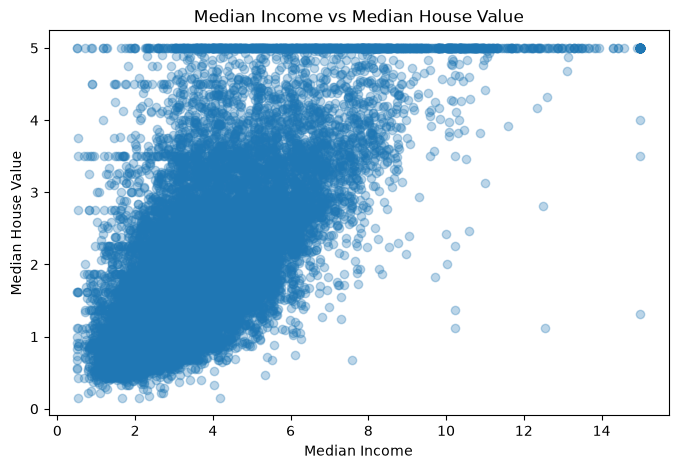

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    california_csv["MedInc"],
    california_csv["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

PART B
## B. Web Service (API) Data Source - Toronto, Ontario

For the web service data source, data is retrieved from the City of Toronto Open Data Portal.

The purpose of this section is to demonstrate how data can be collected from a web service using Python instead of manually downloading a file.

The `requests` library is used to communicate with the Toronto Open Data API. The returned data is then converted into a Pandas DataFrame for analysis.

Source: City of Toronto Open Data Portal

In [11]:
import requests
import pandas as pd

### Retrieve Dataset Information from the API

The Toronto Open Data API is used to retrieve information about the
Building Permits - Cleared Permits dataset.

Building permit data provides information about construction and development
activity associated with properties in Toronto.

In [12]:
package_url = (
    "https://ckan0.cf.opendata.inter.prod-toronto.ca/"
    "api/3/action/package_show"
)

params = {
    "id": "building-permits-cleared-permits"
}

response = requests.get(package_url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [13]:
#convert the response to JSON format
data = response.json()

print("API Success:", data["success"])

API Success: True


In [14]:
#inspect the dataset information
dataset = data["result"]

print("Dataset:", dataset["title"])

Dataset: Building Permits - Cleared Permits


In [15]:
#Find the available resources
resources = dataset["resources"]

for resource in resources:
    print(
        resource.get("name"),
        "-",
        resource.get("format")
    )

Cleared Building Permits since 2017 - CSV
Cleared Building Permits since 2017.csv - CSV
Cleared Building Permits since 2017.xml - XML
Cleared Building Permits since 2017.json - JSON
Cleared Permits 2000 to 2016 - CSV


### Identify Available CSV Resources

The API response may contain multiple resources in different file formats.
The following step filters the available resources and identifies the CSV
files that can be loaded into Pandas for analysis.

In [ ]:
# Find CSV resources
 = [
    resource
    for resource in resources
    if resource.get("format", "").upper() == "CSV"
]

print("Number of CSV resources:", len(csv_resources))
csv_resources
for resource in csv_resources:
    print(resource.get("name"))

Number of CSV resources: 3
Cleared Building Permits since 2017
Cleared Building Permits since 2017.csv
Cleared Permits 2000 to 2016


In [17]:
# Display the URL of the first CSV resource
csv_url = csv_resources[0]["url"]

print("CSV URL:")
print(csv_url)

CSV URL:
https://ckan0.cf.opendata.inter.prod-toronto.ca/datastore/dump/a96c0ba4-3026-402b-b09d-5b1268b8f810


### Load the API Data into a DataFrame

The CSV resource URL obtained from the Toronto Open Data API is loaded
directly into a Pandas DataFrame. This allows the API data to be explored
and analyzed using Python.

In [18]:
# Load the CSV resource into a Pandas DataFrame
toronto_df = pd.read_csv(csv_url)

# Display the first 5 rows
toronto_df.head()

C:\Users\pree0\AppData\Local\Temp\ipykernel_56208\638423557.py:2: DtypeWarning: Columns (2: REVISION_NUM) have mixed types. Specify dtype option on import or set low_memory=False.
  toronto_df = pd.read_csv(csv_url)


,_id,PERMIT_NUM,REVISION_NUM,PERMIT_TYPE,STRUCTURE_TYPE,WORK,STREET_NUM,STREET_NAME,STREET_TYPE,STREET_DIRECTION,...,EST_CONST_COST,ASSEMBLY,INSTITUTIONAL,RESIDENTIAL,BUSINESS_AND_PERSONAL_SERVICES,MERCANTILE,INDUSTRIAL,INTERIOR_ALTERATIONS,DEMOLITION,BUILDER_NAME
0,1,09 183908 DRN,00,Drain and Site Service,SFD - Detached,Building Permit Related (DR),156,ST GERMAIN,AVE,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2,09 196624 DRN,00,Drain and Site Service,SFD - Semi-Detached,Building Permit Related (DR),12,LEEDS,ST,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,3,09 179375 DRN,00,Drain and Site Service,SFD - Detached,Building Permit Related (DR),168,GLENVALE,BLVD,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,4,10 116931 DRN,00,Drain and Site Service,SFD - Detached,Building Permit Related (DR),12,ST ANDREWS,GDNS,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,5,09 177306 DRN,00,Drain and Site Service,SFD - Semi-Detached,Building Permit Related (DR),146,MAJOR,ST,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


### Inspect the Dataset

The number of rows and columns is checked to understand the size of the
dataset. The first few records and column names are also examined to
understand the available information.

In [20]:
print("Number of rows:", toronto_df.shape[0])
print("Number of columns:", toronto_df.shape[1])

toronto_df.columns

toronto_df.info()

Number of rows: 439771
Number of columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 439771 entries, 0 to 439770
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   _id                             439771 non-null  int64  
 1   PERMIT_NUM                      439771 non-null  str    
 2   REVISION_NUM                    439771 non-null  object 
 3   PERMIT_TYPE                     439771 non-null  str    
 4   STRUCTURE_TYPE                  437535 non-null  str    
 5   WORK                            439694 non-null  str    
 6   STREET_NUM                      439766 non-null  str    
 7   STREET_NAME                     439766 non-null  str    
 8   STREET_TYPE                     439771 non-null  str    
 9   STREET_DIRECTION                439771 non-null  str    
 10  POSTAL                          439771 non-null  str    
 11  GEO_ID                          430426 non-n

In [21]:
toronto_df.isnull().sum()

_id                                    0
PERMIT_NUM                             0
REVISION_NUM                           0
PERMIT_TYPE                            0
STRUCTURE_TYPE                      2236
WORK                                  77
STREET_NUM                             5
STREET_NAME                            5
STREET_TYPE                            0
STREET_DIRECTION                       0
POSTAL                                 0
GEO_ID                              9345
WARD_GRID                              5
APPLICATION_DATE                       6
ISSUED_DATE                        34739
COMPLETED_DATE                         0
STATUS                                 0
DESCRIPTION                          635
CURRENT_USE                        30091
PROPOSED_USE                       28073
DWELLING_UNITS_CREATED            283849
DWELLING_UNITS_LOST               285240
EST_CONST_COST                     17798
ASSEMBLY                               0
INSTITUTIONAL   

### Summary Statistics

Summary statistics are generated for the numerical columns to understand
their distribution, range, mean, and other basic characteristics.

In [22]:
toronto_df.describe()

,_id,GEO_ID,DWELLING_UNITS_CREATED,DWELLING_UNITS_LOST,ASSEMBLY,INSTITUTIONAL,RESIDENTIAL,BUSINESS_AND_PERSONAL_SERVICES,MERCANTILE,INDUSTRIAL,INTERIOR_ALTERATIONS,DEMOLITION
count,439771.000000,4.304260e+05,155922.000000,154531.000000,439771.000000,439771.000000,439771.000000,4.397710e+05,439771.000000,439771.000000,439770.000000,439771.000000
mean,219886.000000,6.106805e+06,0.902175,0.091703,2.338578,0.996787,35.654339,1.505486e+01,1.397713,11.735799,38.376252,15.082113
std,126951.096953,6.961229e+06,17.090489,1.676259,120.316428,368.372397,868.005998,7.553382e+03,85.122851,498.299780,430.848841,493.107916
min,1.000000,1.000000e+00,-13.000000,0.000000,0.000000,0.000000,-148.618000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,109943.500000,7.646080e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,219886.000000,3.563882e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,329828.500000,9.278370e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,439771.000000,6.003081e+07,1531.000000,275.000000,28225.000000,235000.000000,128902.000000,5.000000e+06,21105.330000,126213.400000,123303.000000,124267.430000


In [23]:
toronto_df.columns

Index(['_id', 'PERMIT_NUM', 'REVISION_NUM', 'PERMIT_TYPE', 'STRUCTURE_TYPE',
       'WORK', 'STREET_NUM', 'STREET_NAME', 'STREET_TYPE', 'STREET_DIRECTION',
       'POSTAL', 'GEO_ID', 'WARD_GRID', 'APPLICATION_DATE', 'ISSUED_DATE',
       'COMPLETED_DATE', 'STATUS', 'DESCRIPTION', 'CURRENT_USE',
       'PROPOSED_USE', 'DWELLING_UNITS_CREATED', 'DWELLING_UNITS_LOST',
       'EST_CONST_COST', 'ASSEMBLY', 'INSTITUTIONAL', 'RESIDENTIAL',
       'BUSINESS_AND_PERSONAL_SERVICES', 'MERCANTILE', 'INDUSTRIAL',
       'INTERIOR_ALTERATIONS', 'DEMOLITION', 'BUILDER_NAME'],
      dtype='str')

### Basic Exploration of Toronto Building Permit Data

The Toronto API dataset contains building permit and property-related
information, including permit type, structure type, residential use,
dwelling units, and estimated construction cost.

Basic exploratory analysis is performed to understand the structure,
missing values, and numerical characteristics of the dataset.

In [24]:
print("Number of rows:", toronto_df.shape[0])
print("Number of columns:", toronto_df.shape[1])

toronto_df.info()

Number of rows: 439771
Number of columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 439771 entries, 0 to 439770
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   _id                             439771 non-null  int64  
 1   PERMIT_NUM                      439771 non-null  str    
 2   REVISION_NUM                    439771 non-null  object 
 3   PERMIT_TYPE                     439771 non-null  str    
 4   STRUCTURE_TYPE                  437535 non-null  str    
 5   WORK                            439694 non-null  str    
 6   STREET_NUM                      439766 non-null  str    
 7   STREET_NAME                     439766 non-null  str    
 8   STREET_TYPE                     439771 non-null  str    
 9   STREET_DIRECTION                439771 non-null  str    
 10  POSTAL                          439771 non-null  str    
 11  GEO_ID                          430426 non-n

In [25]:
toronto_df["RESIDENTIAL"].value_counts(dropna=False)

RESIDENTIAL
0.00        399998
1.00           372
10.00          284
5.00           178
20.00          126
             ...  
14808.00         1
19829.63         1
24732.00         1
50464.10         1
223.26           1
Name: count, Length: 17167, dtype: int64

In [26]:
toronto_df[
    [
        "PERMIT_TYPE",
        "STRUCTURE_TYPE",
        "CURRENT_USE",
        "PROPOSED_USE",
        "DWELLING_UNITS_CREATED",
        "EST_CONST_COST",
        "RESIDENTIAL"
    ]
].head(10)

,PERMIT_TYPE,STRUCTURE_TYPE,CURRENT_USE,PROPOSED_USE,DWELLING_UNITS_CREATED,EST_CONST_COST,RESIDENTIAL
0,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
1,Drain and Site Service,SFD - Semi-Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
2,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
3,Drain and Site Service,SFD - Detached,Sfd Detatched,Same,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
4,Drain and Site Service,SFD - Semi-Detached,Sfd-Semi,Same,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
5,Drain and Site Service,SFD - Detached,Sfd - One Storey,Sfd - Two Storey,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
6,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
7,Drain and Site Service,SFD - Semi-Detached,Sfd Semi,Same,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
8,Drain and Site Service,Apartment Building,Vacant,Seniors Apartment Building,NaN,"100,000",0.0
9,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,2000,0.0


In [27]:
toronto_df["RESIDENTIAL"].value_counts(dropna=False)

RESIDENTIAL
0.00        399998
1.00           372
10.00          284
5.00           178
20.00          126
             ...  
14808.00         1
19829.63         1
24732.00         1
50464.10         1
223.26           1
Name: count, Length: 17167, dtype: int64

In [28]:
toronto_df[
    [
        "PERMIT_TYPE",
        "STRUCTURE_TYPE",
        "CURRENT_USE",
        "PROPOSED_USE",
        "DWELLING_UNITS_CREATED",
        "EST_CONST_COST",
        "RESIDENTIAL"
    ]
].head(10)

,PERMIT_TYPE,STRUCTURE_TYPE,CURRENT_USE,PROPOSED_USE,DWELLING_UNITS_CREATED,EST_CONST_COST,RESIDENTIAL
0,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
1,Drain and Site Service,SFD - Semi-Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
2,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
3,Drain and Site Service,SFD - Detached,Sfd Detatched,Same,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
4,Drain and Site Service,SFD - Semi-Detached,Sfd-Semi,Same,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
5,Drain and Site Service,SFD - Detached,Sfd - One Storey,Sfd - Two Storey,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
6,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
7,Drain and Site Service,SFD - Semi-Detached,Sfd Semi,Same,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
8,Drain and Site Service,Apartment Building,Vacant,Seniors Apartment Building,NaN,"100,000",0.0
9,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,2000,0.0


In [33]:
toronto_df["STRUCTURE_TYPE"].value_counts().head(20)


STRUCTURE_TYPE
SFD - Detached                      170829
SFD - Semi-Detached                  40038
Office                               36577
SFD - Townhouse                      24447
Apartment Building                   18600
2 Unit - Detached                    14580
Retail Store                         14088
First Party                          11094
Multiple Unit Building               11088
Stacked Townhouses                    9492
Multiple Use/Non Residential          7998
Restaurant 30 Seats or Less           6903
Other                                 6889
2 Unit - Semi-detached                5674
Restaurant Greater Than 30 Seats      5428
Industrial                            4902
Laneway / Rear Yard Suite             4083
Mixed Use/Res w Non Res               3332
3+ Unit - Detached                    3297
Medical/Dental Office                 3286
Name: count, dtype: int64

In [35]:
toronto_df["EST_CONST_COST"].head(10)


0    DO NOT UPDATE OR DELETE THIS INFO FIELD
1    DO NOT UPDATE OR DELETE THIS INFO FIELD
2    DO NOT UPDATE OR DELETE THIS INFO FIELD
3    DO NOT UPDATE OR DELETE THIS INFO FIELD
4    DO NOT UPDATE OR DELETE THIS INFO FIELD
5    DO NOT UPDATE OR DELETE THIS INFO FIELD
6    DO NOT UPDATE OR DELETE THIS INFO FIELD
7    DO NOT UPDATE OR DELETE THIS INFO FIELD
8                                    100,000
9                                       2000
Name: EST_CONST_COST, dtype: str

In [36]:
print(toronto_df["EST_CONST_COST"].dtype)

str


In [37]:
toronto_df[
    ["STRUCTURE_TYPE", "DWELLING_UNITS_CREATED", "EST_CONST_COST"]
].head(20)

,STRUCTURE_TYPE,DWELLING_UNITS_CREATED,EST_CONST_COST
0,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
1,SFD - Semi-Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
2,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
3,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
4,SFD - Semi-Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
5,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
6,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
7,SFD - Semi-Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
8,Apartment Building,NaN,"100,000"
9,SFD - Detached,NaN,2000


In [38]:
toronto_df["STRUCTURE_TYPE"].value_counts().head(20)

STRUCTURE_TYPE
SFD - Detached                      170829
SFD - Semi-Detached                  40038
Office                               36577
SFD - Townhouse                      24447
Apartment Building                   18600
2 Unit - Detached                    14580
Retail Store                         14088
First Party                          11094
Multiple Unit Building               11088
Stacked Townhouses                    9492
Multiple Use/Non Residential          7998
Restaurant 30 Seats or Less           6903
Other                                 6889
2 Unit - Semi-detached                5674
Restaurant Greater Than 30 Seats      5428
Industrial                            4902
Laneway / Rear Yard Suite             4083
Mixed Use/Res w Non Res               3332
3+ Unit - Detached                    3297
Medical/Dental Office                 3286
Name: count, dtype: int64

In [39]:
# Convert estimated construction cost to numeric
toronto_df["EST_CONST_COST"] = pd.to_numeric(
    toronto_df["EST_CONST_COST"],
    errors="coerce"
)

toronto_df["EST_CONST_COST"].describe()

count    1.467770e+05
mean     3.375993e+05
std      5.630455e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.200000e+04
75%      1.000000e+05
max      1.000000e+09
Name: EST_CONST_COST, dtype: float64

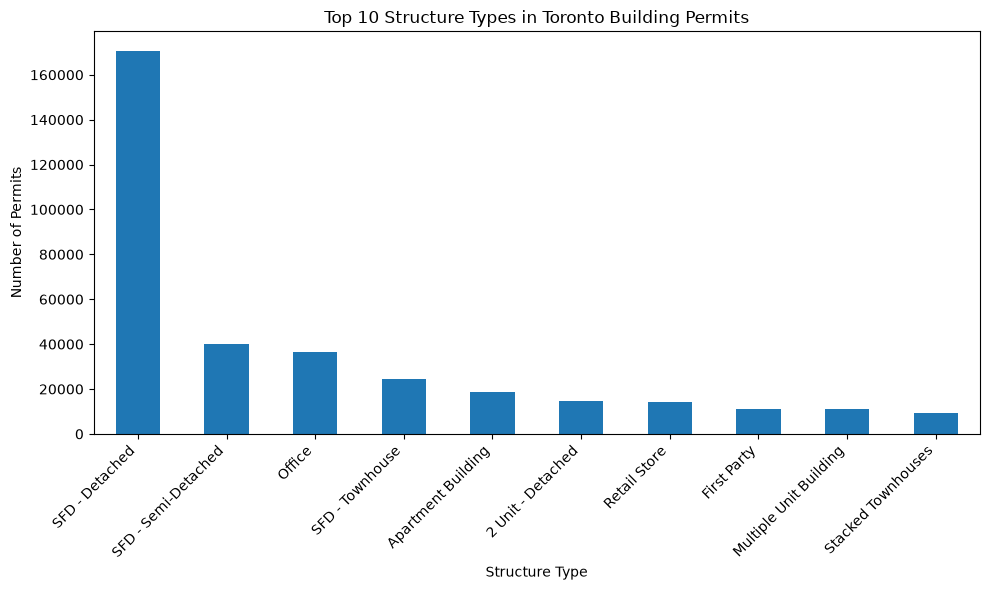

In [40]:
import matplotlib.pyplot as plt

structure_counts = toronto_df["STRUCTURE_TYPE"].value_counts().head(10)

plt.figure(figsize=(10, 6))
structure_counts.plot(kind="bar")

plt.title("Top 10 Structure Types in Toronto Building Permits")
plt.xlabel("Structure Type")
plt.ylabel("Number of Permits")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

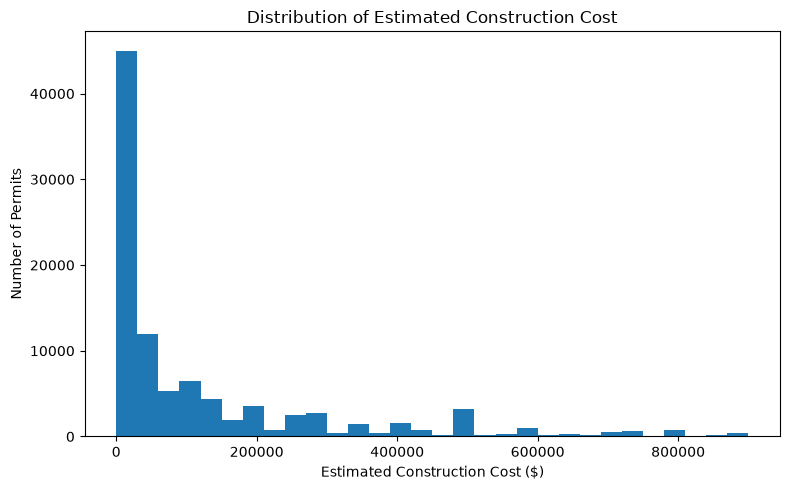

In [41]:
# Keep valid positive construction costs
cost_data = toronto_df.loc[
    toronto_df["EST_CONST_COST"] > 0,
    "EST_CONST_COST"
].dropna()

# Remove extreme values from the visualization
upper_limit = cost_data.quantile(0.95)
cost_plot_data = cost_data[cost_data <= upper_limit]

plt.figure(figsize=(8, 5))

plt.hist(cost_plot_data, bins=30)

plt.title("Distribution of Estimated Construction Cost")
plt.xlabel("Estimated Construction Cost ($)")
plt.ylabel("Number of Permits")

plt.tight_layout()
plt.show()

### Dwelling Units Created

The number of dwelling units created through building permits is examined
to understand how the dataset represents residential development activity.

In [42]:
toronto_df["DWELLING_UNITS_CREATED"] = pd.to_numeric(
    toronto_df["DWELLING_UNITS_CREATED"],
    errors="coerce"
)

toronto_df["DWELLING_UNITS_CREATED"].describe()

count    155922.000000
mean          0.902175
std          17.090489
min         -13.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1531.000000
Name: DWELLING_UNITS_CREATED, dtype: float64

PART C
## Relational Database Data Source - SQLite

For the relational database source, SQLite is used to store and retrieve
the California Housing dataset.

The housing data is inserted into a relational database table and SQL
queries are used to retrieve and filter the records.

SQLite is used because it is lightweight, portable, and does not require
a separate database server.

In [43]:
import sqlite3
import pandas as pd
from pathlib import Path

In [44]:
# Create database folder if it does not exist
db_folder = Path("data/database")
db_folder.mkdir(parents=True, exist_ok=True)

db_path = db_folder / "housing.db"

print("Database path:", db_path)

Database path: data\database\housing.db


In [45]:
california_df = pd.read_csv(
    "data/raw/california_housing.csv"
)

california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [46]:
#connect to the SQLite database

# Connect to SQLite database
conn = sqlite3.connect(db_path)

print("Connected to SQLite database successfully.")

Connected to SQLite database successfully.


In [47]:
#store the California Housing DataFrame in the SQLite database

california_df.to_sql(
    "california_housing",
    conn,
    if_exists="replace",
    index=False
)

print("Housing data stored successfully.")

Housing data stored successfully.


In [48]:
# Querry data from the SQLite database
 
query = """
SELECT *
FROM california_housing;
"""

housing_db_df = pd.read_sql_query(query, conn)

housing_db_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [49]:
# this query retrieves areas where the median house value is
# greater than 3

query_filtered = """
SELECT
    MedInc,
    HouseAge,
    AveRooms,
    MedHouseVal
FROM california_housing
WHERE MedHouseVal > 3;
"""

filtered_housing_df = pd.read_sql_query(
    query_filtered,
    conn
)

filtered_housing_df.head()

,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [50]:
print("Number of filtered records:", filtered_housing_df.shape[0])

filtered_housing_df.head()

Number of filtered records: 3836


,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [51]:
# basic EDA

print("Number of filtered records:", filtered_housing_df.shape[0])

filtered_housing_df.head()

Number of filtered records: 3836


,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [52]:
# basic EDA

housing_db_df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

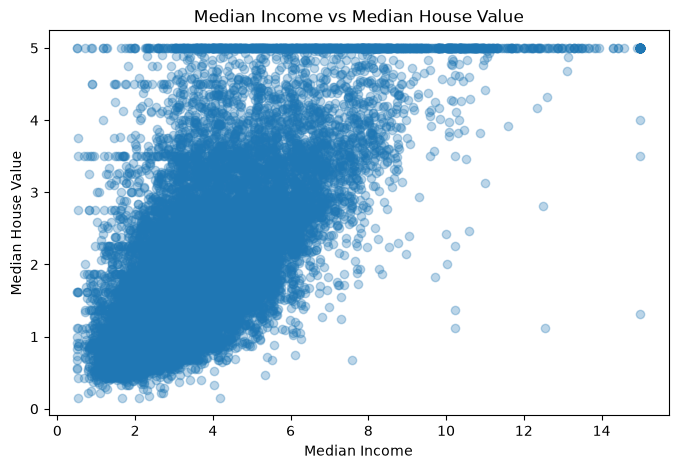

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    housing_db_df["MedInc"],
    housing_db_df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

In [54]:
# close connection to the SQLite database
conn.close()

print("Database connection closed.")

Database connection closed.
